In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import pickle

from mci_progression_ml.dataset.dataset import create_dataset
from mci_progression_ml.framework.nested_cv.method import nested_cv
from mci_progression_ml.framework.nested_cv.dataset_split import create_train_test_split
from mci_progression_ml.framework.model_config import xgb, rf, lr, svc
from mci_progression_ml.framework.nested_cv.summary import summarize_family
from mci_progression_ml.utils import convert
from mci_progression_ml.config import RANDOM_STATE, cog, dem, fs_col, num_features, cat_features
from mci_progression_ml.framework.final.method import final_deployment_model
from mci_progression_ml.framework.final.metrics import bootstrap_metrics
from mci_progression_ml.framework.utils import inspect_dropped_features, get_selected_feature_names

In [2]:
len(fs_col)

323

In [3]:
df = create_dataset()

DIAGNOSIS_24
0    1306
1     702
Name: count, dtype: int64


In [4]:
print("Number of unique subjects:", df["RID"].nunique())
print("Unique subjects by diagnosis:")
print(df.groupby("DIAGNOSIS_24")["RID"].nunique())

rids_sMCI = set(df[df["DIAGNOSIS_24"] == 0]["RID"])
rids_pMCI = set(df[df["DIAGNOSIS_24"] == 1]["RID"])

common_rids = rids_sMCI & rids_pMCI
print("Number of common subjects between sMCI and pMCI:", len(common_rids))


Number of unique subjects: 828
Unique subjects by diagnosis:
DIAGNOSIS_24
0    577
1    347
Name: RID, dtype: int64
Number of common subjects between sMCI and pMCI: 96


In [5]:
outer_cv, \
cv, \
X_train, \
X_test, \
y_train, \
y_test, \
groups_train, \
groups_test, \
diag_change_train, \
diag_change_test = create_train_test_split(
    df,
    ocv_n_splits=5,
    ocv_n_repeats=5,
    icv_n_splits=5,
)


In [6]:
print("Train and test shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

unique_rid_train = np.unique(groups_train).size
unique_rid_test = np.unique(groups_test).size
print("Unique RIDs - Train:", unique_rid_train, "Test:", unique_rid_test)

train_values, train_count = np.unique(y_train, return_counts=True)
test_values, test_count = np.unique(y_test, return_counts=True)

print("Training set class distribution:")
print(dict(zip(train_values, train_count)))
print("Test set class distribution:")
print(dict(zip(test_values, test_count)))

Train and test shapes: (1607, 334) (1607,) (401, 334) (401,)
Unique RIDs - Train: 664 Test: 164
Training set class distribution:
{np.int64(0): np.int64(1045), np.int64(1): np.int64(562)}
Test set class distribution:
{np.int64(0): np.int64(261), np.int64(1): np.int64(140)}


In [7]:
import csv

with open("mci_progression_ml/dataset/freesurfer_mapping.csv", mode="r") as f:
    row = csv.DictReader(f)
    row_list = list(row)

    feature_map = {entry["fs_col"]: entry["fs_description"] for entry in row_list}

feature_map["MMSCORE"] = "MMSE"
feature_map["TOTAL13"] = "ADAS13"
feature_map["TOTSCORE"] = "ADAS11"
feature_map["FAQTOTAL"] = "FAQ"

df = df.rename(columns=feature_map)

In [8]:
df_filtered = df[["MMSE", "CDGLOBAL", "CDRSB", "ADAS11", "ADAS13", "FAQ", "AGE", "PTEDUCAT", "DIAGNOSIS_24", 'APOE4', 'PTGENDER', 'PTHAND']]
features = ["MMSE", "CDGLOBAL", "CDRSB", "ADAS11", "ADAS13", "FAQ", "AGE", "PTEDUCAT"]

summary_table = pd.DataFrame(index=features)



# Overall
summary_table[('Overall', 'Mean')] = df_filtered[features].mean()
summary_table[('Overall', 'SD')] = df_filtered[features].std()
summary_table[('Overall', 'Median')] = df_filtered[features].median()

# sMCI
smci_df = df_filtered[df_filtered['DIAGNOSIS_24'] == 0]
summary_table[('sMCI', 'Mean')] = smci_df[features].mean()
summary_table[('sMCI', 'SD')] = smci_df[features].std()
summary_table[('sMCI', 'Median')] = smci_df[features].median()

# pMCI
pmci_df = df_filtered[df_filtered['DIAGNOSIS_24'] == 1]
summary_table[('pMCI', 'Mean')] = pmci_df[features].mean()
summary_table[('pMCI', 'SD')] = pmci_df[features].std()
summary_table[('pMCI', 'Median')] = pmci_df[features].median()

summary_table = summary_table.round(4)
summary_table.columns = pd.MultiIndex.from_tuples(summary_table.columns)
summary_table.index.name = 'Feature'

display(summary_table)

Overall                     sMCI                    pMCI          \
             Mean      SD  Median     Mean      SD Median     Mean      SD   
Feature                                                                      
MMSE      27.4323  2.1399  28.000  28.0842  1.8234  28.00  26.2194  2.1579   
CDGLOBAL   0.4856  0.1322   0.500   0.4663  0.1398   0.50   0.5214  0.1080   
CDRSB      1.6731  1.1107   1.500   1.3070  0.9124   1.00   2.3540  1.1263   
ADAS11    10.3672  4.8838   9.670   8.5018  3.8529   8.00  13.8376  4.7019   
ADAS13    16.6461  7.3121  16.330  13.6228  5.9119  13.00  22.2707  6.2694   
FAQ        3.7654  4.5038   2.000   2.3660  3.4574   1.00   6.3689  5.0384   
AGE       74.8171  7.5011  75.185  74.6966  7.5895  75.06  75.0412  7.3339   
PTEDUCAT  15.9338  2.7857  16.000  15.9847  2.8134  16.00  15.8390  2.7327   

                 
         Median  
Feature          
MMSE      26.00  
CDGLOBAL   0.50  
CDRSB      2.00  
ADAS11    13.33  
ADAS13    22.00  
FAQ        6.00  
AGE       75.43  
PTEDUCAT  16.00

In [9]:
features = ['APOE4', 'PTGENDER', 'PTHAND']

def cat_group_stats(df, name):
    rows = []

    for col in features:
        counts = df[col].value_counts(dropna=False).sort_index()
        total = counts.sum()

        for cat, cnt in counts.items():
            rows.append({
                'Feature': col,
                'Category': cat,
                f'{name}': cnt,
            })

    return pd.DataFrame(rows).set_index(['Feature', 'Category'])


# -------------------------
# Split groups
# -------------------------
overall_df = df_filtered
smci_df = df_filtered[df_filtered['DIAGNOSIS_24'] == 0]
pmci_df = df_filtered[df_filtered['DIAGNOSIS_24'] == 1]

# -------------------------
# Build tables
# -------------------------
overall = cat_group_stats(overall_df, "overall")
smci = cat_group_stats(smci_df, "sMCI")
pmci = cat_group_stats(pmci_df, "pMCI")


# -------------------------
# Combine
# -------------------------
cat_table = pd.concat([overall, smci, pmci], axis=1)

cat_table = cat_table.round(2)

display(cat_table)

overall  sMCI  pMCI
Feature  Category                     
APOE4    0.0          1013   780   233
         1.0           784   427   357
         2.0           211    99   112
PTGENDER 0.0          1209   791   418
         1.0           799   515   284
PTHAND   0.0          1825  1178   647
         1.0           183   128    55

In [10]:
with open('results/nested_cv_results.json', 'r') as file:
    results = json.load(file)

In [11]:
# ---- Build summary dataframe for Logistic Regression variants ----
summary = [
    summarize_family(k, v)
    for result in results
    for k, v in result.items()
]

df_results = pd.DataFrame(summary)

# Split the family column into parts
# Format: model-modality-sampling
df_results[['model', 'modality', 'sampling']] = df_results['family'].str.split('-', expand=True)
df_results['sampling'] = df_results['sampling'].replace({
    'smote': 'SMOTENC',
    'smote_tomek': 'SMOTENC-Tomek',
    'none': 'None'
})
df_results['model'] = df_results['model'].str.upper().str.replace('CLASSIFIER', '', regex=False).str.strip()
df_results['model'] = df_results['model'].replace({
    'LOGISTICREGRESSION': 'LR',
    'RANDOMFOREST': 'RF',
})

df_results['modality'] = df_results['modality'].str.upper().str.replace('_', '-').str.strip()


# Sort by macro F1 mean (primary), then PR-AUC mean (secondary)
df_results = df_results.sort_values(
    by="balanced_acc_mean",
    ascending=False
).reset_index(drop=True)

In [12]:
# Top 5 configurations based on balanced accuracy mean
df_results[['model', 'modality', 'sampling', 'f1_macro_mean', 'f1_macro_sd', 'balanced_acc_mean', 'balanced_acc_sd',
    'pr_auc_mean', 'pr_auc_sd', 'sensitivity_mean', 'sensitivity_sd', 'specificity_mean', 'specificity_sd'
    ]].sort_values(
    by="balanced_acc_mean",
    ascending=False
).head(5)

,model,modality,sampling,f1_macro_mean,f1_macro_sd,balanced_acc_mean,balanced_acc_sd,pr_auc_mean,pr_auc_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd
0,XGB,DEM-COG-MRI,SMOTENC,0.796646,0.029460,81.278287,2.562859,0.791195,0.044695,83.168050,5.014685,79.388524,5.536546
1,XGB,DEM-COG-MRI,SMOTENC-Tomek,0.794031,0.024636,81.099713,2.321635,0.783581,0.046242,83.313453,5.356778,78.885973,4.800682
2,SVC,DEM-COG-MRI,SMOTENC-Tomek,0.792413,0.029703,80.981744,2.918791,0.802207,0.044043,83.410787,5.301360,78.552701,4.491193
3,SVC,DEM-COG-MRI,SMOTENC,0.790270,0.030926,80.913035,2.892465,0.798551,0.045936,83.985071,5.204380,77.840999,5.021134
4,XGB,DEM-COG-MRI,None,0.788157,0.028972,80.804946,2.954164,0.789983,0.045907,84.304282,5.573400,77.305610,4.296607


In [13]:
# Top configurations abalation study for the best model (XGB) and best modality (DEM-COG-MRI)
best_model_ablation = df_results[(df_results['model'] == 'XGB') & (df_results['modality'] == 'DEM-COG-MRI')]
best_model_ablation[['model', 'modality', 'sampling', 'f1_macro_mean', 'f1_macro_sd', 'balanced_acc_mean', 'balanced_acc_sd',
    'pr_auc_mean', 'pr_auc_sd', 'sensitivity_mean', 'sensitivity_sd', 'specificity_mean', 'specificity_sd'
    ]].sort_values(
    by="balanced_acc_mean",
    ascending=False
)

,model,modality,sampling,f1_macro_mean,f1_macro_sd,balanced_acc_mean,balanced_acc_sd,pr_auc_mean,pr_auc_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd
0,XGB,DEM-COG-MRI,SMOTENC,0.796646,0.029460,81.278287,2.562859,0.791195,0.044695,83.168050,5.014685,79.388524,5.536546
1,XGB,DEM-COG-MRI,SMOTENC-Tomek,0.794031,0.024636,81.099713,2.321635,0.783581,0.046242,83.313453,5.356778,78.885973,4.800682
4,XGB,DEM-COG-MRI,None,0.788157,0.028972,80.804946,2.954164,0.789983,0.045907,84.304282,5.573400,77.305610,4.296607


In [14]:
# Top configurations abalation study for the best model (XGB) and best sampling method (SMOTENC)
best_model_ablation = df_results[(df_results['model'] == 'XGB') & (df_results['sampling'] == 'SMOTENC')]
best_model_ablation[['model', 'modality', 'sampling', 'f1_macro_mean', 'f1_macro_sd', 'balanced_acc_mean', 'balanced_acc_sd',
    'pr_auc_mean', 'pr_auc_sd', 'sensitivity_mean', 'sensitivity_sd', 'specificity_mean', 'specificity_sd'
    ]].sort_values(
    by="balanced_acc_mean",
    ascending=False
)

,model,modality,sampling,f1_macro_mean,f1_macro_sd,balanced_acc_mean,balanced_acc_sd,pr_auc_mean,pr_auc_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd
0,XGB,DEM-COG-MRI,SMOTENC,0.796646,0.029460,81.278287,2.562859,0.791195,0.044695,83.168050,5.014685,79.388524,5.536546
12,XGB,COG-MRI,SMOTENC,0.788823,0.029170,80.620500,2.720852,0.775596,0.048414,83.020723,4.793498,78.220277,4.788439
23,XGB,DEM-COG,SMOTENC,0.787763,0.021034,79.779179,2.118219,0.790538,0.038632,78.544749,5.279308,81.013608,4.074623
45,XGB,COG,SMOTENC,0.775140,0.029339,78.902815,2.525771,0.778652,0.050686,79.466677,4.839341,78.338953,5.659034
51,XGB,MRI-DEM,SMOTENC,0.721115,0.042778,73.399169,4.278140,0.689309,0.056277,72.594714,8.174006,74.203623,6.710238
69,XGB,MRI,SMOTENC,0.692530,0.040008,70.925993,3.667586,0.655233,0.054454,71.741336,8.613863,70.110650,8.481456
76,XGB,DEM,SMOTENC,0.600652,0.041998,61.953160,4.477851,0.464327,0.047783,64.345887,8.627481,59.560434,6.120490


  model       sampling     modality              6 month             12 month  \
0   XGB        SMOTENC  DEM-COG-MRI  95.01 [93.51–96.50]  87.06 [84.80–89.32]   
1   XGB  SMOTENC-Tomek  DEM-COG-MRI  95.08 [93.17–96.98]  86.02 [83.53–88.52]   
2   SVC  SMOTENC-Tomek  DEM-COG-MRI  93.99 [92.20–95.79]  86.51 [84.17–88.84]   
3   SVC        SMOTENC  DEM-COG-MRI  93.22 [91.25–95.19]  87.54 [85.73–89.34]   
4   XGB           None  DEM-COG-MRI  94.69 [92.91–96.47]  87.20 [84.81–89.58]   

              24 month  
0  73.59 [70.57–76.61]  
1  74.73 [71.56–77.90]  
2  75.16 [72.05–78.27]  
3  76.14 [72.81–79.47]  
4  76.28 [72.91–79.65]  


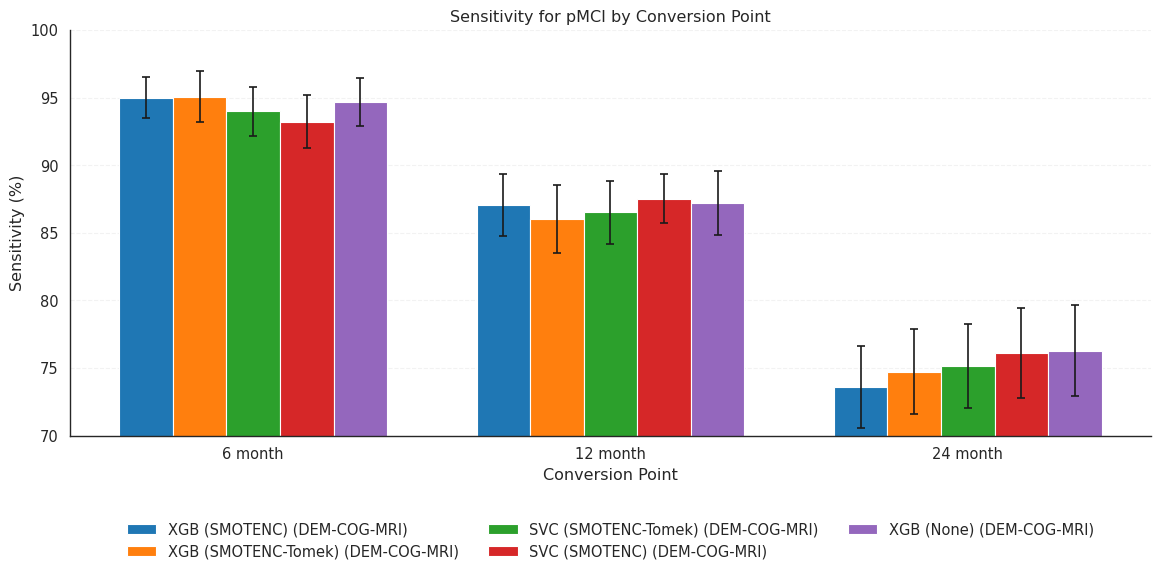

In [15]:
from mci_progression_ml.plots.conversion_point import sensitivity_by_conversion_point
sensitivity_by_conversion_point(df_results)

In [16]:
df_modality = (
    df_results.groupby('modality')
    .agg({
        'f1_macro_mean': ['mean', 'std'],
        'pr_auc_mean': ['mean', 'std'],
        'roc_auc_mean': ['mean', 'std'],
        'balanced_acc_mean': ['mean', 'std'],
        'sensitivity_mean': ['mean', 'std'],
        'specificity_mean': ['mean', 'std'],
    })
    .reset_index()
)

# Flatten columns
df_modality.columns = ['_'.join(col).strip('_') for col in df_modality.columns]

df_modality.sort_values(
    "balanced_acc_mean_mean",
    ascending=False
)

,modality,f1_macro_mean_mean,f1_macro_mean_std,pr_auc_mean_mean,pr_auc_mean_std,roc_auc_mean_mean,roc_auc_mean_std,balanced_acc_mean_mean,balanced_acc_mean_std,sensitivity_mean_mean,sensitivity_mean_std,specificity_mean_mean,specificity_mean_std
4,DEM-COG-MRI,0.788832,0.005819,0.794110,0.015234,0.889558,0.006107,80.624111,0.581136,82.999746,0.946189,78.248477,0.771818
1,COG-MRI,0.785981,0.006699,0.786139,0.016484,0.885436,0.006112,80.281419,0.610806,82.353238,0.916281,78.209600,1.020443
3,DEM-COG,0.784140,0.002644,0.795124,0.005158,0.880540,0.003124,79.598151,0.245289,79.212735,0.739728,79.983567,0.664472
0,COG,0.777530,0.002855,0.784091,0.008261,0.874738,0.004871,79.124539,0.292518,79.652615,0.532151,78.596464,0.378459
6,MRI-DEM,0.714515,0.006117,0.689435,0.010701,0.806626,0.005329,73.040438,0.607645,73.820971,1.647591,72.259904,1.403894
5,MRI,0.698495,0.007543,0.661419,0.013020,0.790453,0.006522,71.649434,0.657622,73.341864,1.289437,69.957003,1.511263
2,DEM,0.600602,0.004157,0.469095,0.008884,0.631963,0.004179,61.795586,0.324483,63.416021,0.825721,60.175152,1.008791


In [17]:
df_sampling = (
    df_results.groupby('sampling')
    .agg({
        'f1_macro_mean': ['mean', 'std'],
        'pr_auc_mean': ['mean', 'std'],
        'roc_auc_mean': ['mean', 'std'],
        'balanced_acc_mean': ['mean', 'std'],
        'sensitivity_mean': ['mean', 'std'],
        'specificity_mean': ['mean', 'std'],
    })
    .reset_index()
)

df_sampling.columns = ['_'.join(col).strip('_') for col in df_sampling.columns]

df_sampling.sort_values(
    "balanced_acc_mean_mean",
    ascending=False
)

,sampling,f1_macro_mean_mean,f1_macro_mean_std,pr_auc_mean_mean,pr_auc_mean_std,roc_auc_mean_mean,roc_auc_mean_std,balanced_acc_mean_mean,balanced_acc_mean_std,sensitivity_mean_mean,sensitivity_mean_std,specificity_mean_mean,specificity_mean_std
2,SMOTENC-Tomek,0.736953,0.066857,0.711560,0.113213,0.822790,0.088660,75.276402,6.590930,76.473909,6.622298,74.078895,6.734544
0,None,0.734695,0.065517,0.712303,0.113983,0.822841,0.087873,75.101920,6.451847,76.591757,6.418790,73.612083,6.786928
1,SMOTENC,0.735536,0.066662,0.710171,0.113955,0.822646,0.087581,75.098969,6.569042,76.133129,6.580268,74.064808,6.798962


In [18]:
df_model = (
    df_results.groupby('model')
    .agg({
        'f1_macro_mean': ['mean', 'std'],
        'pr_auc_mean': ['mean', 'std'],
        'roc_auc_mean': ['mean', 'std'],
        'balanced_acc_mean': ['mean', 'std'],
        'sensitivity_mean': ['mean', 'std'],
        'specificity_mean': ['mean', 'std'],
    })
    .reset_index()
)

df_model.columns = ['_'.join(col).strip('_') for col in df_model.columns]

df_model.sort_values(
    "balanced_acc_mean_mean",
    ascending=False
)

,model,f1_macro_mean_mean,f1_macro_mean_std,pr_auc_mean_mean,pr_auc_mean_std,roc_auc_mean_mean,roc_auc_mean_std,balanced_acc_mean_mean,balanced_acc_mean_std,sensitivity_mean_mean,sensitivity_mean_std,specificity_mean_mean,specificity_mean_std
2,SVC,0.737664,0.066717,0.718953,0.112397,0.825868,0.088656,75.378617,6.601654,76.753363,6.720143,74.003872,6.698516
0,LR,0.738259,0.065961,0.721754,0.116995,0.825364,0.092316,75.368970,6.502249,76.448283,6.433688,74.289657,6.696774
3,XGB,0.736634,0.068454,0.706894,0.114215,0.822244,0.087185,75.243502,6.744326,76.435323,6.826620,74.051681,7.017011
1,RF,0.730354,0.065592,0.697777,0.112347,0.817560,0.085800,74.645298,6.433975,75.961425,6.320339,73.329171,6.820828


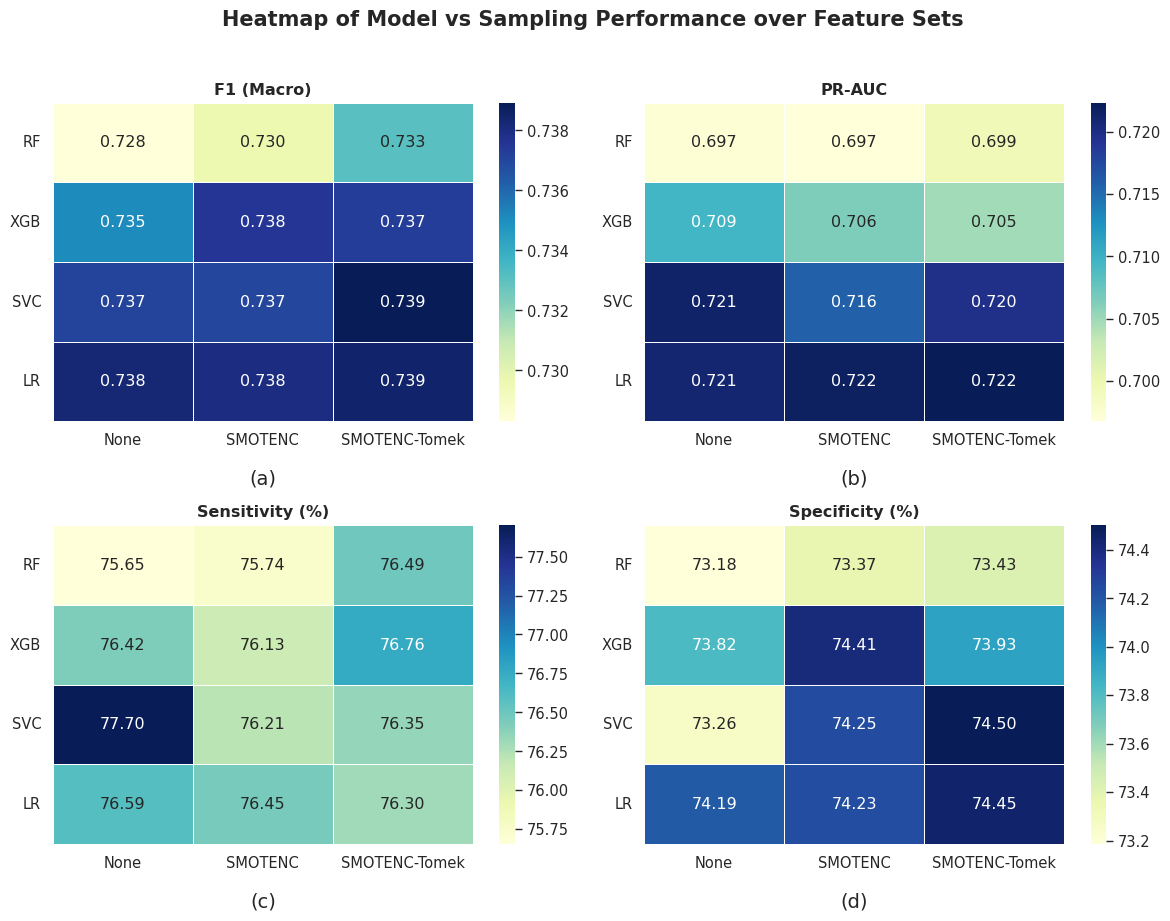

In [19]:
from mci_progression_ml.plots.headmaps import plot_heatmap
plot_heatmap(df_results, None, "over Feature Sets")

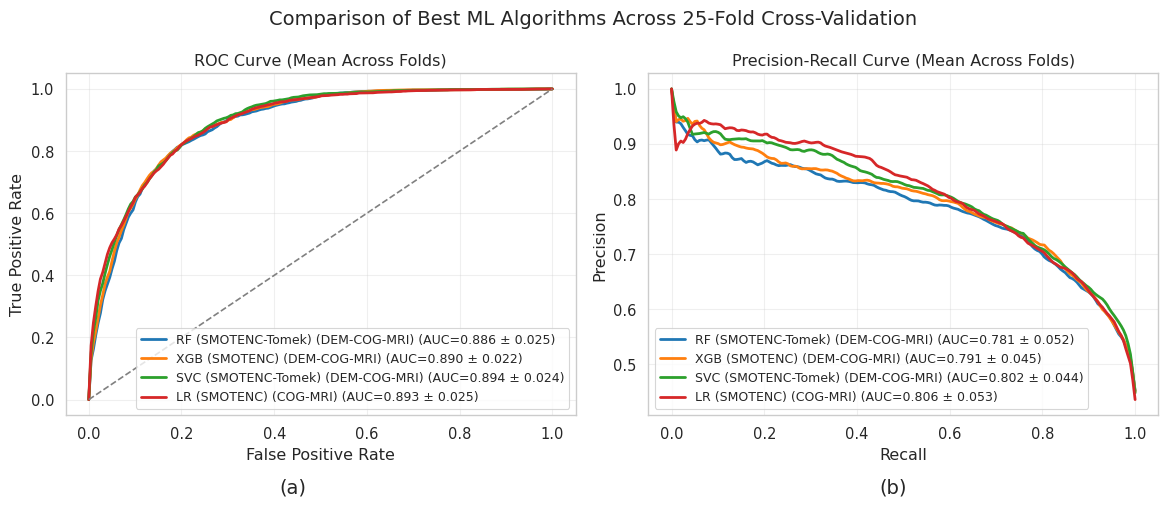

In [20]:
from mci_progression_ml.plots.roc_pr import plot_mean_roc_pr_curves
flat_results = {k: v for d in results for k, v in d.items()}
model_results = {
    "RF (SMOTENC-Tomek) (DEM-COG-MRI)": flat_results.get("randomforestclassifier-dem_cog_mri-smote_tomek"),
    "XGB (SMOTENC) (DEM-COG-MRI)": flat_results.get("xgbclassifier-dem_cog_mri-smote"),
    "SVC (SMOTENC-Tomek) (DEM-COG-MRI)": flat_results.get("svc-dem_cog_mri-smote_tomek"),
    "LR (SMOTENC) (COG-MRI)": flat_results.get("logisticregression-cog_mri-smote"),
}
plot_mean_roc_pr_curves(model_results, "Best ML Algorithms")

In [21]:
import json

with open("results/nested_cv_result_best_configuration_with_xai.json", mode="r") as f:
    model_results = json.load(f)

In [22]:
from mci_progression_ml.framework.xai.metrics import xai_summary

features = cog + dem + fs_col

aggregated_xai = xai_summary(model_results, features=features, feature_map=feature_map)


In [44]:
aggregated_xai.to_csv("results/aggregated_xai.csv", index=False)


In [23]:
shap_0_xai = aggregated_xai[['feature', 'selected_count', 'selection_frequency', 'shap_class0_all_folds', 'shap_class0_selected_only']].sort_values(
    by='shap_class0_all_folds', ascending=False)

shap_0_xai.head(20)

,feature,selected_count,selection_frequency,shap_class0_all_folds,shap_class0_selected_only
1,FAQ,25,1.00,0.066689,0.066689
0,ADAS13,23,0.92,0.066075,0.071821
2,CDRSB,25,1.00,0.041907,0.041907
3,APOE4,25,1.00,0.029101,0.029101
4,MMSE,25,1.00,0.027512,0.027512
5,ADAS11,25,1.00,0.016962,0.016962
6,SV - LeftInferiorLateralVentricle,23,0.92,0.013114,0.014254
7,SV - LeftHippocampus,25,1.00,0.010205,0.010205
8,CT - LeftInferiorParietal,24,0.96,0.006412,0.006679
9,CV - RightInferiorParietal,14,0.56,0.003765,0.006723


In [24]:
shap_1_xai = aggregated_xai[['feature', 'selected_count', 'selection_frequency', 'shap_class1_all_folds', 'shap_class1_selected_only']].sort_values(
    by='shap_class1_all_folds', ascending=False)
shap_1_xai.head(20)

,feature,selected_count,selection_frequency,shap_class1_all_folds,shap_class1_selected_only
0,ADAS13,23,0.92,0.090188,0.098031
1,FAQ,25,1.00,0.084054,0.084054
2,CDRSB,25,1.00,0.057388,0.057388
3,APOE4,25,1.00,0.039806,0.039806
4,MMSE,25,1.00,0.034890,0.034890
5,ADAS11,25,1.00,0.020618,0.020618
6,SV - LeftInferiorLateralVentricle,23,0.92,0.016145,0.017549
7,SV - LeftHippocampus,25,1.00,0.012057,0.012057
8,CT - LeftInferiorParietal,24,0.96,0.008927,0.009299
9,CV - RightInferiorParietal,14,0.56,0.006444,0.011507


In [25]:
shap_balanced_xai = aggregated_xai[['feature', 'selected_count', 'selection_frequency', 'shap_balanced_all_folds', 'shap_balanced_selected_only']].sort_values(
    by='shap_balanced_all_folds', ascending=False)
shap_balanced_xai.head(20)

,feature,selected_count,selection_frequency,shap_balanced_all_folds,shap_balanced_selected_only
0,ADAS13,23,0.92,0.078132,0.084926
1,FAQ,25,1.00,0.075372,0.075372
2,CDRSB,25,1.00,0.049648,0.049648
3,APOE4,25,1.00,0.034453,0.034453
4,MMSE,25,1.00,0.031201,0.031201
5,ADAS11,25,1.00,0.018790,0.018790
6,SV - LeftInferiorLateralVentricle,23,0.92,0.014629,0.015901
7,SV - LeftHippocampus,25,1.00,0.011131,0.011131
8,CT - LeftInferiorParietal,24,0.96,0.007669,0.007989
9,CV - RightInferiorParietal,14,0.56,0.005104,0.009115


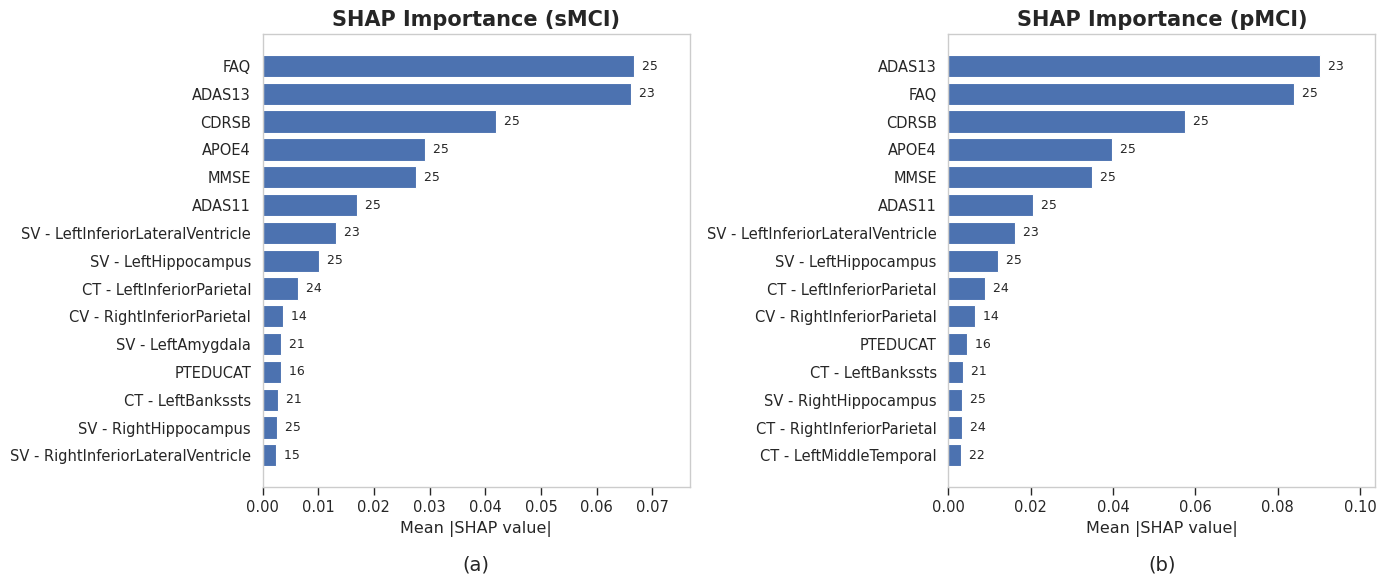

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'SHAP Importance (sMCI)'}, xlabel='Mean |SHAP value|'>,
        <Axes: title={'center': 'SHAP Importance (pMCI)'}, xlabel='Mean |SHAP value|'>],
       dtype=object))

In [26]:
from mci_progression_ml.plots.xai import plot_importance_comparison

plot_importance_comparison(
    shap_0_xai,
    "shap_class0_all_folds",
    'SHAP Importance (sMCI)',
    shap_1_xai,
    "shap_class1_all_folds",
    'SHAP Importance (pMCI)',
    'shap',
    ("a", "b"),
    figsize=(14,6),
    top_k=15,
    output_name="shap_importance_comparison"
)


In [27]:
pi_f1 = aggregated_xai[['feature', 'selected_count', 'selection_frequency', 'permutation_f1_all_folds', 'permutation_f1_selected_only']].sort_values(
    by='permutation_f1_all_folds', ascending=False)
pi_f1.head(20)

,feature,selected_count,selection_frequency,permutation_f1_all_folds,permutation_f1_selected_only
0,ADAS13,23,0.92,0.037625,0.040897
1,FAQ,25,1.00,0.030643,0.030643
2,CDRSB,25,1.00,0.015815,0.015815
3,APOE4,25,1.00,0.011205,0.011205
4,MMSE,25,1.00,0.005217,0.005217
5,ADAS11,25,1.00,0.004271,0.004271
6,SV - LeftInferiorLateralVentricle,23,0.92,0.002899,0.003151
10,PTEDUCAT,16,0.64,0.000702,0.001097
20,CT - RightEntorhinal,22,0.88,0.000534,0.000607
33,CT - RightSuperiorTemporal,16,0.64,0.000484,0.000756


In [28]:
pi_bal_acc = aggregated_xai[['feature', 'selected_count', 'selection_frequency', 'permutation_balanced_acc_all_folds', 'permutation_balanced_acc_selected_only']].sort_values(
    by='permutation_balanced_acc_all_folds', ascending=False)
pi_bal_acc.head(20)

,feature,selected_count,selection_frequency,permutation_balanced_acc_all_folds,permutation_balanced_acc_selected_only
0,ADAS13,23,0.92,0.041531,0.045142
1,FAQ,25,1.00,0.034085,0.034085
2,CDRSB,25,1.00,0.018250,0.018250
3,APOE4,25,1.00,0.011280,0.011280
4,MMSE,25,1.00,0.006410,0.006410
5,ADAS11,25,1.00,0.004844,0.004844
6,SV - LeftInferiorLateralVentricle,23,0.92,0.003230,0.003511
10,PTEDUCAT,16,0.64,0.000605,0.000945
20,CT - RightEntorhinal,22,0.88,0.000565,0.000642
7,SV - LeftHippocampus,25,1.00,0.000537,0.000537


In [29]:
pi_pr_auc = aggregated_xai[['feature', 'selected_count', 'selection_frequency', 'permutation_pr_auc_all_folds', 'permutation_pr_auc_selected_only']].sort_values(
    by='permutation_pr_auc_all_folds', ascending=False)
pi_pr_auc.head(20)

,feature,selected_count,selection_frequency,permutation_pr_auc_all_folds,permutation_pr_auc_selected_only
0,ADAS13,23,0.92,0.052427,0.056986
1,FAQ,25,1.00,0.044601,0.044601
2,CDRSB,25,1.00,0.020500,0.020500
3,APOE4,25,1.00,0.017095,0.017095
4,MMSE,25,1.00,0.010460,0.010460
6,SV - LeftInferiorLateralVentricle,23,0.92,0.005927,0.006443
5,ADAS11,25,1.00,0.005063,0.005063
10,PTEDUCAT,16,0.64,0.001326,0.002072
29,CV - RightSuperiorTemporal,4,0.16,0.001089,0.006804
23,CV - LeftInferiorParietal,14,0.56,0.000934,0.001668


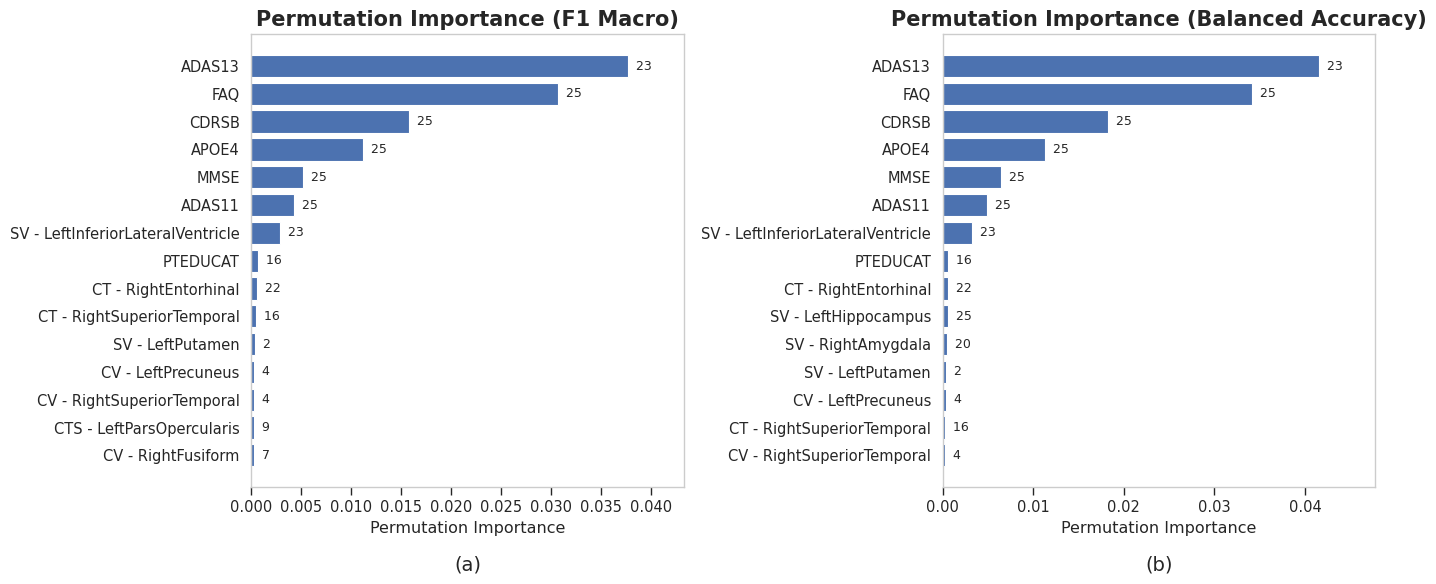

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Permutation Importance (F1 Macro)'}, xlabel='Permutation Importance'>,
        <Axes: title={'center': 'Permutation Importance (Balanced Accuracy)'}, xlabel='Permutation Importance'>],
       dtype=object))

In [30]:
from mci_progression_ml.plots.xai import plot_importance_comparison

plot_importance_comparison(
    pi_f1,
    "permutation_f1_all_folds",
    'Permutation Importance (F1 Macro)',
    pi_bal_acc,
    "permutation_balanced_acc_all_folds",
    'Permutation Importance (Balanced Accuracy)',
    'pi',
    ("a", "b"),
    figsize=(14,6),
    top_k=15,
    output_name="permutation_importance_comparison"
)


In [42]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, kendalltau


# =========================================================
# 1. Define importance columns
# =========================================================

shap_col = "shap_balanced_all_folds"
pi_col = "permutation_balanced_acc_all_folds"


# =========================================================
# 2. Remove features with missing importance values
# =========================================================

valid = aggregated_xai[[shap_col, pi_col]].notna().all(axis=1)

xai_valid = aggregated_xai.loc[valid].copy()

print(f"Number of features analyzed: {len(xai_valid)}")


# =========================================================
# 3. Rank features independently
# =========================================================

shap_ranked = (
    xai_valid
    .sort_values(shap_col, ascending=False)
    .index
    .tolist()
)

pi_ranked = (
    xai_valid
    .sort_values(pi_col, ascending=False)
    .index
    .tolist()
)


# =========================================================
# 4. Top-K feature overlap
# =========================================================

k = 15

top_shap = set(shap_ranked[:k])
top_pi = set(pi_ranked[:k])

intersection = top_shap & top_pi
union = top_shap | top_pi

n_shared = len(intersection)

overlap_rate = n_shared / k
jaccard_sim = n_shared / len(union)


# =========================================================
# 5. Rank agreement among the common Top-K features
# =========================================================

# Features appearing in both Top-K lists
common_features = list(intersection)

# Obtain their ranks in each method
shap_rank_dict = {
    feature: rank
    for rank, feature in enumerate(shap_ranked, start=1)
}

pi_rank_dict = {
    feature: rank
    for rank, feature in enumerate(pi_ranked, start=1)
}

shap_common_ranks = [
    shap_rank_dict[feature]
    for feature in common_features
]

pi_common_ranks = [
    pi_rank_dict[feature]
    for feature in common_features
]


# Kendall's tau
if len(common_features) >= 2:
    tau_top15, p_kendall = kendalltau(
        shap_common_ranks,
        pi_common_ranks
    )
else:
    tau_top15 = np.nan
    p_kendall = np.nan


# =========================================================
# 6. Global rank agreement
# =========================================================

x = xai_valid[shap_col].values
y = xai_valid[pi_col].values

rho_global, p_spearman = spearmanr(x, y)


# =========================================================
# 7. Global magnitude correlation
# =========================================================

r_global, p_pearson = pearsonr(x, y)


# =========================================================
# 8. Rank differences
# =========================================================

rank_difference = pd.DataFrame({
    "SHAP_rank": [shap_rank_dict[f] for f in common_features],
    "PI_rank": [pi_rank_dict[f] for f in common_features]
}, index=common_features)

rank_difference["absolute_rank_difference"] = (
    rank_difference["SHAP_rank"]
    - rank_difference["PI_rank"]
).abs()

if len(rank_difference) > 0:
    mean_abs_rank_difference = (
        rank_difference["absolute_rank_difference"].mean()
    )

    median_abs_rank_difference = (
        rank_difference["absolute_rank_difference"].median()
    )
else:
    mean_abs_rank_difference = np.nan
    median_abs_rank_difference = np.nan


# =========================================================
# 9. Features unique to each Top-K ranking
# =========================================================

shap_only = sorted(top_shap - top_pi)
pi_only = sorted(top_pi - top_shap)


# =========================================================
# 10. Display results
# =========================================================

print("\n=== SHAP vs. Permutation Importance Agreement ===")

print(
    f"\n1. Top-{k} feature overlap:"
    f"\n   {n_shared}/{k} shared ({overlap_rate:.1%})"
)

print(
    f"\n2. Top-{k} Jaccard similarity:"
    f"\n   {jaccard_sim:.3f}"
)

print(
    f"\n3. Kendall's tau among shared Top-{k} features:"
    f"\n   τ = {tau_top15:.3f} "
    f"(p = {p_kendall:.4g})"
)

print(
    f"\n4. Global Spearman correlation:"
    f"\n   ρ = {rho_global:.3f} "
    f"(p = {p_spearman:.4g})"
)

print(
    f"\n5. Global Pearson correlation:"
    f"\n   r = {r_global:.3f} "
    f"(p = {p_pearson:.4g})"
)

print(
    f"\n6. Absolute rank difference among shared Top-{k}:"
    f"\n   Mean   = {mean_abs_rank_difference:.2f}"
    f"\n   Median = {median_abs_rank_difference:.2f}"
)

print(
    f"\n7. SHAP-only Top-{k} features:"
    f"\n   {len(shap_only)}"
)

print(
    f"\n8. PI-only Top-{k} features:"
    f"\n   {len(pi_only)}"
)


# =========================================================
# 11. Detailed Top-K comparison table
# =========================================================

top15_comparison = pd.DataFrame({
    "SHAP_rank": pd.Series(shap_rank_dict),
    "PI_rank": pd.Series(pi_rank_dict)
})

top15_comparison["rank_difference"] = (
    top15_comparison["SHAP_rank"]
    - top15_comparison["PI_rank"]
)

top15_comparison["absolute_rank_difference"] = (
    top15_comparison["rank_difference"].abs()
)

top15_comparison["in_SHAP_top15"] = (
    top15_comparison.index.isin(top_shap)
)

top15_comparison["in_PI_top15"] = (
    top15_comparison.index.isin(top_pi)
)

top15_comparison = top15_comparison[
    top15_comparison["in_SHAP_top15"]
    | top15_comparison["in_PI_top15"]
].sort_values("SHAP_rank")

print("\n=== Top-15 Feature Comparison ===")
print(top15_comparison)


Number of features analyzed: 334

=== SHAP vs. Permutation Importance Agreement ===

1. Top-15 feature overlap:
   9/15 shared (60.0%)

2. Top-15 Jaccard similarity:
   0.429

3. Kendall's tau among shared Top-15 features:
   τ = 0.944 (p = 4.96e-05)

4. Global Spearman correlation:
   ρ = -0.195 (p = 0.0003476)

5. Global Pearson correlation:
   r = 0.966 (p = 4.452e-198)

6. Absolute rank difference among shared Top-15:
   Mean   = 0.56
   Median = 0.00

7. SHAP-only Top-15 features:
   6

8. PI-only Top-15 features:
   6

=== Top-15 Feature Comparison ===
    SHAP_rank  PI_rank  rank_difference  absolute_rank_difference  \
0           1        1                0                         0   
1           2        2                0                         0   
2           3        3                0                         0   
3           4        4                0                         0   
4           5        5                0                         0   
5           6        

In [32]:
aggregated_xai[
    aggregated_xai["total_dropped_count"] > 0
][[
    "feature",
    "selected_count",
    "selection_frequency",
    "variance_dropped_count",
    "variance_dropped_fraction",
    "correlation_dropped_count",
    "correlation_dropped_fraction",
    "total_dropped_count",
    "total_dropped_fraction"
]].sort_values(
    by="total_dropped_count",
    ascending=False
).head(20)

,feature,selected_count,selection_frequency,variance_dropped_count,variance_dropped_fraction,correlation_dropped_count,correlation_dropped_fraction,total_dropped_count,total_dropped_fraction
326,SV - CorticalGM,0,0.00,0,0.0,25,1.00,25,1.00
328,SV - RightCorticalWM,0,0.00,0,0.0,25,1.00,25,1.00
329,SV - CorticalWM,0,0.00,0,0.0,25,1.00,25,1.00
325,SA - RightHemisphereWM,0,0.00,0,0.0,25,1.00,25,1.00
117,SV - RightCorticalGM,9,0.36,0,0.0,2,0.08,2,0.08
0,ADAS13,23,0.92,0,0.0,2,0.08,2,0.08
65,SV - TotalGM,9,0.36,0,0.0,2,0.08,2,0.08
55,SV - LeftPutamen,2,0.08,0,0.0,1,0.04,1,0.04
291,SV - LeftVentralDC,0,0.00,0,0.0,1,0.04,1,0.04
131,SV - SupraTentorial,4,0.16,0,0.0,1,0.04,1,0.04


In [33]:
aggregated_xai[[
    "feature",
    "selected_count",
    "selection_frequency",
    "variance_dropped_count",
    "variance_dropped_fraction",
    "correlation_dropped_count",
    "correlation_dropped_fraction",
    "total_dropped_count",
    "total_dropped_fraction"
]].sort_values(
    by="selected_count",
    ascending=False
).head(20)

,feature,selected_count,selection_frequency,variance_dropped_count,variance_dropped_fraction,correlation_dropped_count,correlation_dropped_fraction,total_dropped_count,total_dropped_fraction
25,CT - RightFusiform,25,1.00,0,0.0,0,0.00,0,0.00
1,FAQ,25,1.00,0,0.0,0,0.00,0,0.00
7,SV - LeftHippocampus,25,1.00,0,0.0,0,0.00,0,0.00
5,ADAS11,25,1.00,0,0.0,0,0.00,0,0.00
4,MMSE,25,1.00,0,0.0,0,0.00,0,0.00
2,CDRSB,25,1.00,0,0.0,0,0.00,0,0.00
13,SV - RightHippocampus,25,1.00,0,0.0,0,0.00,0,0.00
3,APOE4,25,1.00,0,0.0,0,0.00,0,0.00
8,CT - LeftInferiorParietal,24,0.96,0,0.0,0,0.00,0,0.00
18,CT - RightInferiorParietal,24,0.96,0,0.0,0,0.00,0,0.00


In [34]:
import json

with open("results/final_model_independent_test_set_all_features.json", mode="r") as f:
    test_set_result = json.load(f)

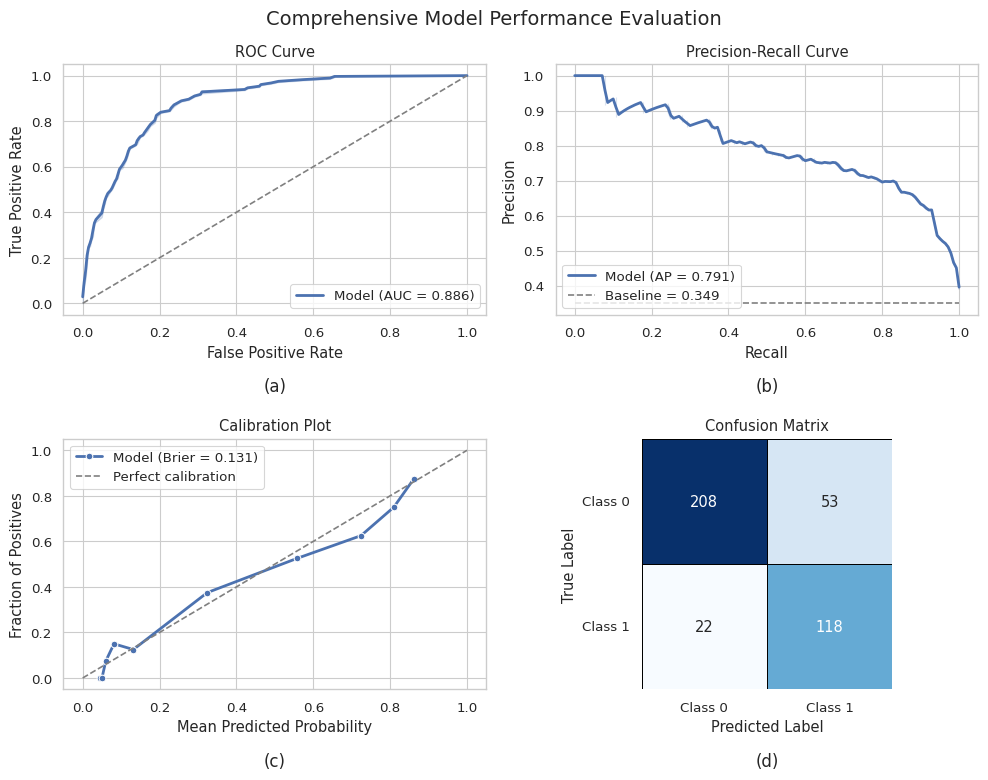

In [35]:
from mci_progression_ml.plots.test_set import plot

plot(test_set_result["y_true"], test_set_result["y_score"], test_set_result["y_pred"])

In [36]:
from mci_progression_ml.framework.final.metrics import print_metrics_with_ci

print_metrics_with_ci(test_set_result["point_metrics"], test_set_result["bootstrap_metrics"])



Confusion Matrix Counts
TN: 208, FP: 53, FN: 22, TP: 118

Class-wise Metrics
Precision (Class 0): 0.9043 (0.9044)(95% CI: 0.8650 - 0.9402)
Precision (Class 1): 0.6901 (0.6894)(95% CI: 0.6235 - 0.7545)
Recall (Class 0): 0.7969 (0.7966)(95% CI: 0.7481 - 0.8421)
Recall (Class 1): 0.8429 (0.8428)(95% CI: 0.7770 - 0.9000)
F1 Score (Class 0): 0.8473 (0.8468)(95% CI: 0.8131 - 0.8776)
F1 Score (Class 1): 0.7588 (0.7578)(95% CI: 0.7063 - 0.8050)

Macro Average Metrics
Precision (Macro): 0.7972 (0.7969)(95% CI: 0.7591 - 0.8331)
Recall (Macro): 0.8199 (0.8197)(95% CI: 0.7822 - 0.8551)
F1 Score (Macro): 0.8030 (0.8023)(95% CI: 0.7628 - 0.8392)

Positive-Class / Threshold Metrics
Precision: 0.6901 (0.6894)(95% CI: 0.6235 - 0.7545)
Recall: 0.8429 (0.8428)(95% CI: 0.7770 - 0.9000)
F1 Score: 0.7588 (0.7578)(95% CI: 0.7063 - 0.8050)
Positive Predictive Value (PPV): 0.6901 (0.6894)(95% CI: 0.6235 - 0.7545)
Negative Predictive Value (NPV): 0.9043 (0.9044)(95% CI: 0.8650 - 0.9402)

Overall Classification

In [37]:
from pprint import pprint

print(f"\nSelected Features ({len(test_set_result['selected_features'])}):")
pprint([feature_map[feature] if feature in feature_map else feature for feature in test_set_result["selected_features"]])

print("\nVariance-Dropped Features:")
print([feature_map[feature] if feature in feature_map else feature for feature in test_set_result["variance_dropped_features"]])

print("\nCorrelation-Dropped Features:")
print([feature_map[feature] if feature in feature_map else feature for feature in test_set_result["correlation_dropped_features"]])

print("\nBest Parameters:")
pprint(test_set_result["params"])


Selected Features (50):
['PTEDUCAT',
 'APOE4',
 'MMSE',
 'CDRSB',
 'ADAS11',
 'ADAS13',
 'FAQ',
 'CTS - RightParsOpercularis',
 'CTS - RightParsTriangularis',
 'CT - RightRostralMiddleFrontal',
 'CTS - RightRostralMiddleFrontal',
 'CTS - RightSuperiorFrontal',
 'CTS - RightSuperiorParietal',
 'CTS - RightSuperiorTemporal',
 'CTS - RightSupramarginal',
 'SA - RightTransverseTemporal',
 'SV - LeftAmygdala',
 'CT - LeftBankssts',
 'CTS - LeftBankssts',
 'CT - LeftEntorhinal',
 'SA - LeftFrontalPole',
 'CT - LeftFusiform',
 'SV - LeftHippocampus',
 'SV - LeftInferiorLateralVentricle',
 'CT - LeftInferiorParietal',
 'CTS - LeftInferiorParietal',
 'CT - LeftInferiorTemporal',
 'CT - LeftMiddleTemporal',
 'CTS - LeftParacentral',
 'CTS - LeftParsOpercularis',
 'CTS - LeftPostcentral',
 'CTS - LeftRostralMiddleFrontal',
 'CTS - LeftSuperiorFrontal',
 'CT - LeftSuperiorParietal',
 'CTS - LeftSuperiorParietal',
 'CT - LeftSuperiorTemporal',
 'CTS - LeftSuperiorTemporal',
 'CT - LeftSupramargina

In [38]:
import json
from mci_progression_ml.framework.final.metrics import metrics_with_ci_df

result_files = {
    "All Features":
        "results/final_model_independent_test_set_all_features.json",

    "Functional Connectivity":
        "results/final_model_independent_test_set_functional_connectivity.json",

    "Cognitive Scores":
        "results/final_model_independent_test_set_cognitive_scores.json",

    "Demographics":
        "results/final_model_independent_test_set_demographics.json",

    "Without APOE4":
        "results/final_model_independent_test_set_without_apoe4.json",

    "Without MMScore":
        "results/final_model_independent_test_set_without_mmscore.json",

    "Without CDRSB":
        "results/final_model_independent_test_set_without_cdrsb.json",

    "Without TOTAL13":
        "results/final_model_independent_test_set_without_total13.json",

    "Without FAQTOTAL":
        "results/final_model_independent_test_set_without_faqtotal.json",
}

results = {}

for name, filepath in result_files.items():
    with open(filepath, "r") as f:
        test_set_result = json.load(f)

    results[name] = {
        "point": test_set_result["point_metrics"],
        "bootstrap": test_set_result["bootstrap_metrics"],
        "threshold": test_set_result["threshold"],
        "selected_features": test_set_result["selected_features"],
    }

df = metrics_with_ci_df(
    results,
    confidence=0.95,
    digits=4,
    compare_against="All Features",
    compare_metric="balanced_accuracy",
)

print(df.to_string())


                  Ablation  Threshold  selected_features                       PPV                       NPV               Sensitivity               Specificity         Balanced Accuracy                                                   Comparison Difference       Comparison CI Significant
0             All Features   0.370410                 50  0.6901 [0.6235 - 0.7545]  0.9043 [0.8650 - 0.9402]  0.8429 [0.7770 - 0.9000]  0.7969 [0.7481 - 0.8421]  0.8199 [0.7822 - 0.8551]                                                    Reference  Reference           Reference   Reference
1  Functional Connectivity   0.385009                150  0.6301 [0.5596 - 0.7048]  0.8640 [0.8162 - 0.9107]  0.7786 [0.7067 - 0.8496]  0.7548 [0.7025 - 0.8078]  0.7667 [0.7225 - 0.8121]  All Features vs Functional Connectivity (Balanced Accuracy)     0.0522   [0.0066 - 0.0949]        True
2         Cognitive Scores   0.320391                  6  0.6412 [0.5706 - 0.7101]  0.8658 [0.8225 - 0.9068]  0.7786 [0.7095 - 